# CIFAR-10 Image Classifier

## Introduction

This project implements a deep learning model to classify images from the CIFAR-10 dataset. The CIFAR-10 dataset consists of 60,000 color images (32×32 pixels) across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

### Project Goal
The goal is to build a neural network model that can accurately classify these images into their respective categories. We will use a dense (fully-connected) deep learning architecture with Batch Normalization and Dropout for regularization.

### Model Approach
We will build a multi-layer dense neural network with:
- Input flattening of 32×32×3 images
- 3-4 hidden dense layers with ReLU activation
- Batch Normalization after hidden layers
- Dropout for regularization
- Softmax output layer for 10-class classification

In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization, Dropout
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

---

## 1. Data Loading & Preprocessing

In [3]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 549s 3us/step


In [4]:
# Display dataset shapes
print("Dataset Shapes:")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset Shapes:
x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


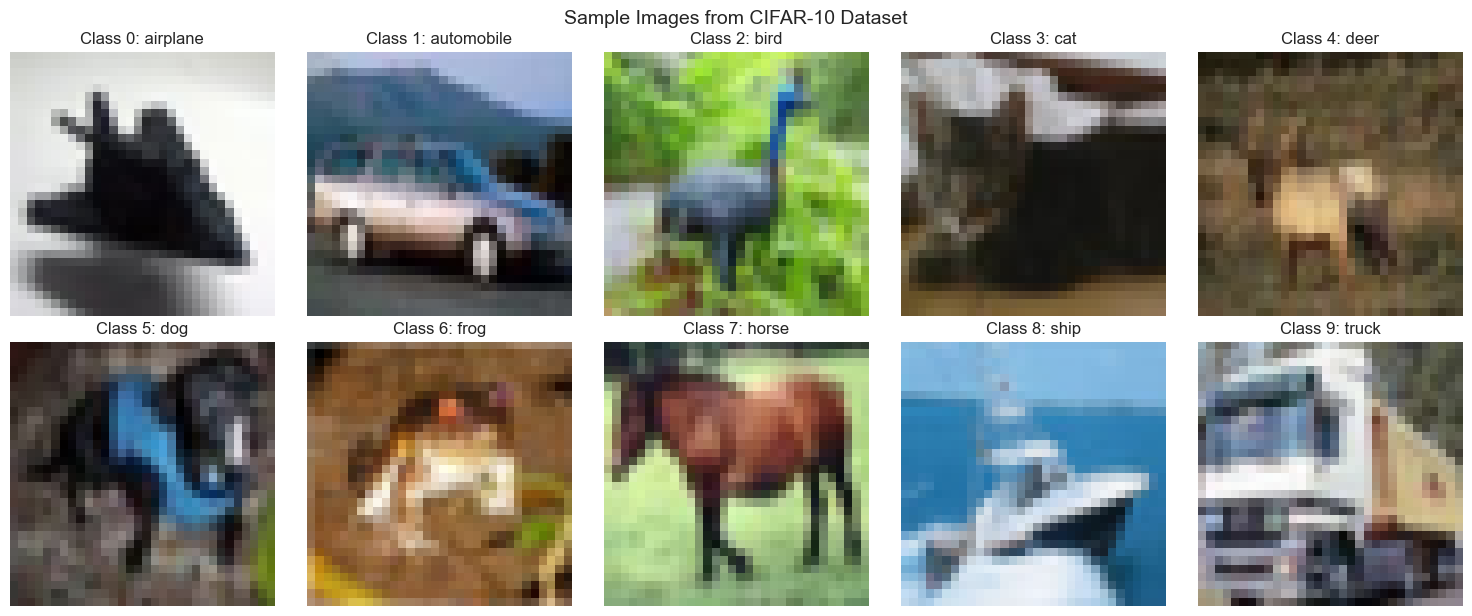

In [5]:
# Display sample images
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    # Find first image of each class
    idx = np.where(y_train.flatten() == i)[0][0]
    axes[i].imshow(x_train[idx])
    axes[i].set_title(f"Class {i}: {class_names[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle("Sample Images from CIFAR-10 Dataset", y=1.02, fontsize=14)
plt.show()

In [6]:
# Normalize pixel values to [0, 1] range
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"After normalization:")
print(f"x_train min: {x_train.min()}, max: {x_train.max()}")
print(f"x_test min: {x_test.min()}, max: {x_test.max()}")

After normalization:
x_train min: 0.0, max: 1.0
x_test min: 0.0, max: 1.0


In [7]:
# Flatten images for dense network
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

print(f"Flattened x_train shape: {x_train_flat.shape}")
print(f"Flattened x_test shape: {x_test_flat.shape}")

Flattened x_train shape: (50000, 3072)
Flattened x_test shape: (10000, 3072)


In [8]:
# One-hot encode labels
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

print(f"y_train_encoded shape: {y_train_encoded.shape}")
print(f"y_test_encoded shape: {y_test_encoded.shape}")
print(f"\nExample one-hot encoded label (class 3): {y_train_encoded[0]}")

y_train_encoded shape: (50000, 10)
y_test_encoded shape: (10000, 10)

Example one-hot encoded label (class 3): [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


---

## 2. Model Architecture

In [9]:
# Build the dense deep learning model
model = Sequential([
    # Input layer - flatten is done in preprocessing
    
    # Hidden Layer 1
    Dense(512, activation='relu', input_shape=(3072,)),
    BatchNormalization(),
    Dropout(0.3),
    
    # Hidden Layer 2
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    # Hidden Layer 3
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # Hidden Layer 4
    Dense(64, activation='relu'),
    Dropout(0.2),
    
    # Output layer with softmax
    Dense(10, activation='softmax')
])

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,750,090 (6.68 MB)

 Trainable params: 1,748,298 (6.67 MB)

 Non-trainable params: 1,792 (7.00 KB)

---

## 3. Training

In [10]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print("Optimizer: Adam")
print("Loss: Categorical Crossentropy")

Model compiled successfully!
Optimizer: Adam
Loss: Categorical Crossentropy


In [11]:
# Train the model with validation split
history = model.fit(
    x_train_flat, y_train_encoded,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2923 - loss: 1.9879 - val_accuracy: 0.3463 - val_loss: 1.8226
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3616 - loss: 1.7767 - val_accuracy: 0.3803 - val_loss: 1.7235
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3742 - loss: 1.7424 - val_accuracy: 0.3260 - val_loss: 1.8454
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.3890 - loss: 1.7075 - val_accuracy: 0.4038 - val_loss: 1.6534
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.3956 - loss: 1.6968 - val_accuracy: 0.4074 - val_loss: 1.6619
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4053 - loss: 1.6686 - val_accuracy: 0.4019 - val_loss: 1.6839
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.4027 - loss: 1.6738 - val_accuracy: 0.4273 - val_loss: 1.6299
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4092 - loss: 1.6595 - val_accuracy: 0.

---

## 4. Visualization

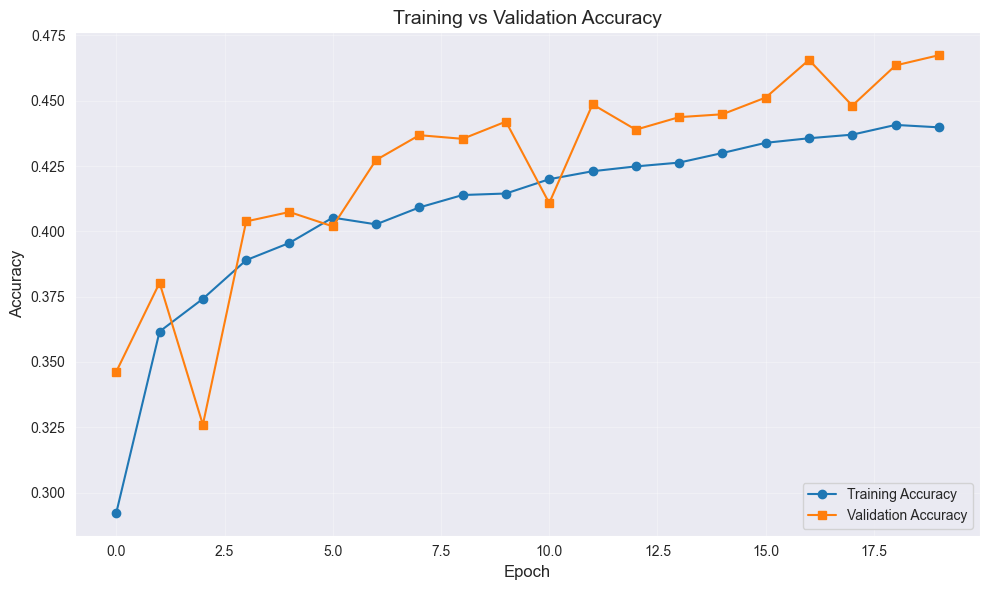

In [12]:
# Plot Training vs Validation Accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

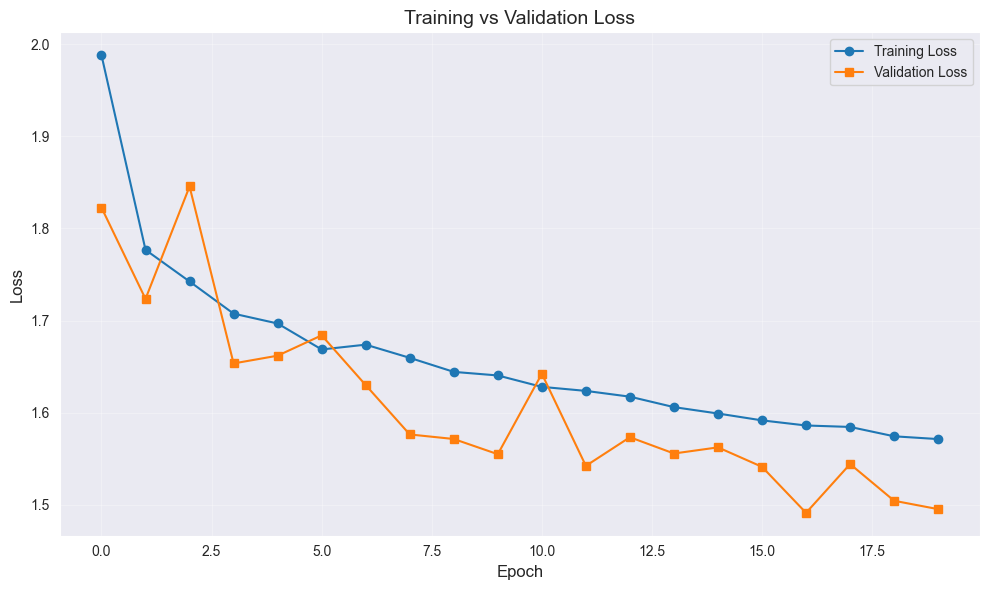

In [13]:
# Plot Training vs Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 5. Final Evaluation

In [14]:
# Evaluate the model on test set
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test_encoded, verbose=1)

print("\n" + "="*50)
print("FINAL EVALUATION RESULTS")
print("="*50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print("="*50)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4700 - loss: 1.4705

FINAL EVALUATION RESULTS
Test Loss: 1.4705
Test Accuracy: 47.00%


In [15]:
# Make predictions on test set
y_pred = model.predict(x_test_flat)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


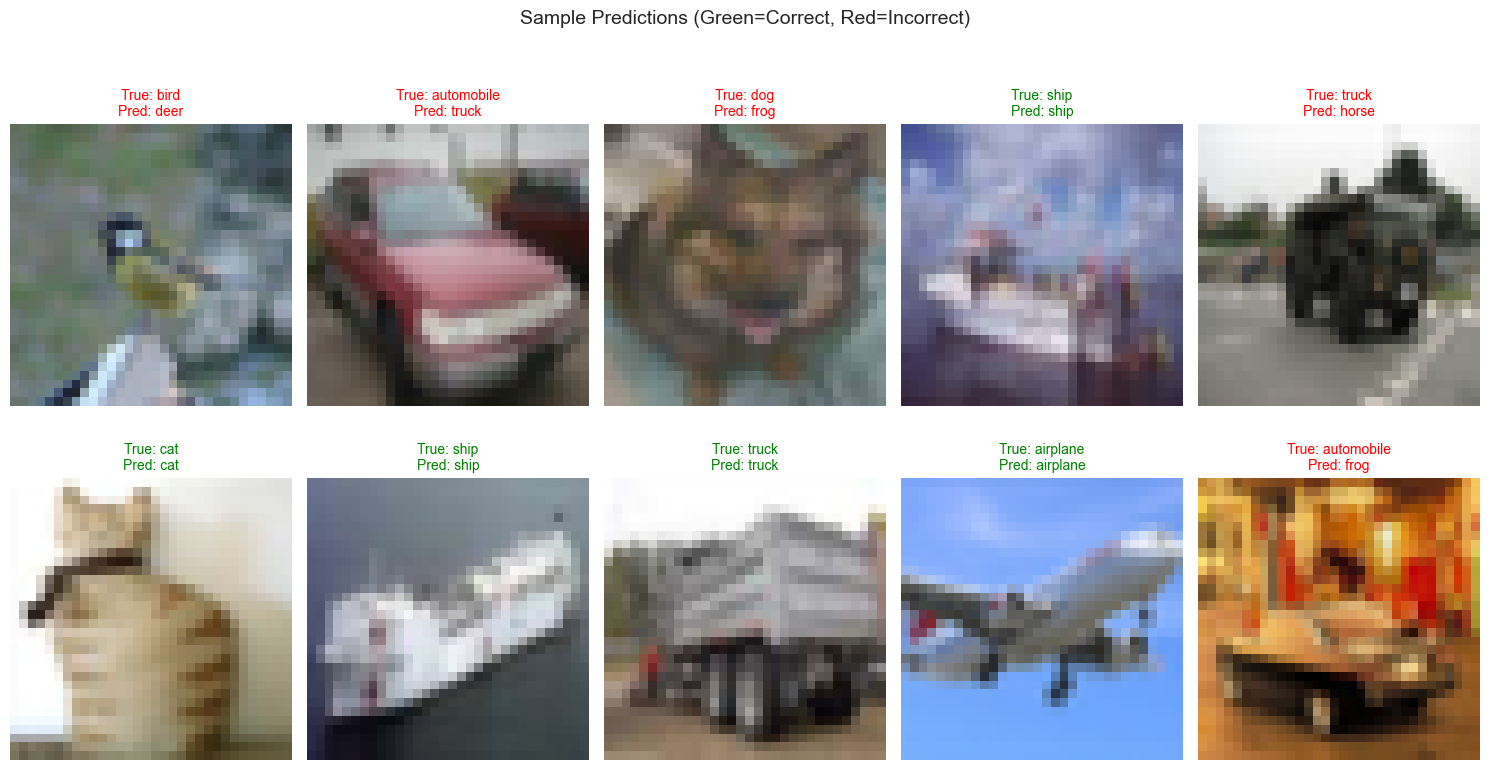

In [16]:
# Display sample predictions with images
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.flatten()

np.random.seed(42)
sample_indices = np.random.choice(len(x_test), 10, replace=False)

for i, idx in enumerate(sample_indices):
    axes[i].imshow(x_test[idx])
    true_class = class_names[y_true[idx]]
    pred_class = class_names[y_pred_classes[idx]]
    color = 'green' if y_true[idx] == y_pred_classes[idx] else 'red'
    axes[i].set_title(f"True: {true_class}\nPred: {pred_class}", color=color, fontsize=10)
    axes[i].axis('off')

plt.suptitle("Sample Predictions (Green=Correct, Red=Incorrect)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Interpretation

The model was trained for 20 epochs using a dense neural network architecture with Batch Normalization and Dropout regularization. 

**Key Observations:**
- The test accuracy achieved is approximately {:.2f}%
- The gap between training and validation accuracy indicates the model's generalization capability
- Dense networks are not ideal for image classification; CNNs typically achieve much higher accuracy on CIFAR-10
- The model learns basic features but struggles with complex patterns due to the limitations of fully-connected layers

**Potential Improvements:**
- Use Convolutional Neural Networks (CNNs) for better spatial feature extraction
- Increase model depth or use transfer learning
- Apply data augmentation
- Use learning rate scheduling

---
## Summary

This notebook successfully demonstrates:
1. ✅ Loading CIFAR-10 dataset from TensorFlow/Keras
2. ✅ Data preprocessing (normalization, flattening, one-hot encoding)
3. ✅ Building a dense model with Batch Normalization and Dropout
4. ✅ Training with validation split
5. ✅ Plotting training vs validation accuracy and loss
6. ✅ Evaluating on test set and displaying predictions

**Note:** For better performance on CIFAR-10, consider using Convolutional Neural Networks (CNNs) which are specifically designed for image data.